<a href="https://colab.research.google.com/github/radevicstefan-afk/DSB-MTN-Git-Starter/blob/main/Titanic_excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno


In [16]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/radevicstefan-afk/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv")

In [17]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


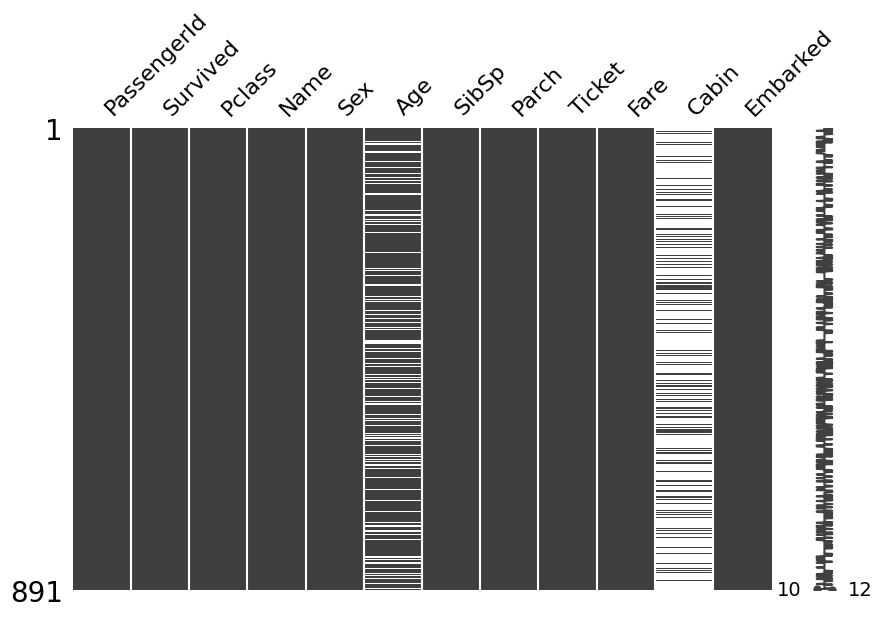

In [20]:
#Create a bar chart showing how many missing values are in each column
msno.matrix(titanic_df, figsize=(10,6));


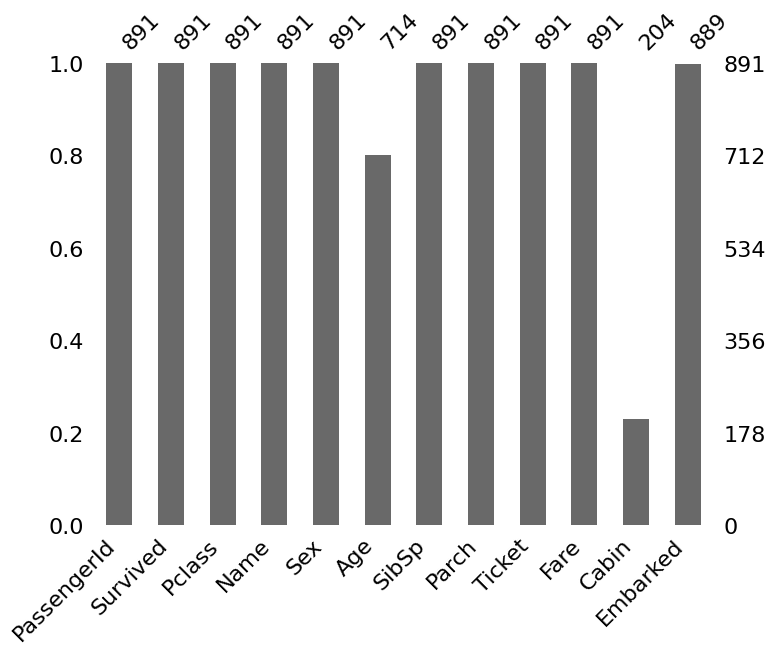

In [21]:
#Which column has the most NaN values? How many cells in that column are empty?

msno.bar(titanic_df, figsize=(8, 6));

In [22]:
#Delete all rows where Embarked is empty

filter = titanic_df["Embarked"].notna()
Embarked_df = titanic_df[filter]

In [23]:
# Fill all empty cabins with ¯\(ツ)/¯

titanic_df["Cabin"] = titanic_df["Cabin"].fillna("¯\\*(ツ)*/¯")


In [24]:
#Step 3: Feature extractio
#1.There are two columns that pertain to how many family members are on the boat for a given person.
#Create a new column called FamilyCount which will be the sum of those two columns.

titanic_df["FamilyCount"] = titanic_df["SibSp"] + titanic_df["Parch"]

titanic_df["FamilyCount"].head()


,FamilyCount
0,1
1,1
2,0
3,1
4,0


In [25]:
#2.Reverends have a special title in their name. Create a column called IsReverend: 1 if they're a preacher, 0 if they're not.
titanic_df["IsReverend"] = titanic_df["Name"].str.contains("Rev.").astype(int)
titanic_df["IsReverend"].head()

,IsReverend
0,0
1,0
2,0
3,0
4,0


In [26]:
#In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using pd.get_dummies

titanic_df = pd.get_dummies(titanic_df, columns=["Embarked", "Sex"], dtype=int)

In [27]:
#Step 4: Exploratory analysis
#What was the survival rate overall?

titanic_df["Survived"].mean()

survival_rate = titanic_df["Survived"].mean() * 100
print(survival_rate)


38.38383838383838


In [39]:
#Which gender fared the worst? What was their survival rate?

titanic_df.columns



Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilyCount', 'IsReverend', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Sex_female', 'Sex_male'],
      dtype='object')

In [40]:
titanic_df.groupby("Sex_male")["Survived"].mean() * 100

,Survived
Sex_male,
0,74.203822
1,18.890815


In [41]:
titanic_df.groupby("Sex_female")["Survived"].mean() * 100

,Survived
Sex_female,
0,18.890815
1,74.203822


In [43]:
female_survival = titanic_df[titanic_df["Sex_female"] == 1]["Survived"].mean() * 100
male_survival = titanic_df[titanic_df["Sex_male"] == 1]["Survived"].mean() * 100

print("Female survival rate:", female_survival)
print("Male survival rate:", male_survival)

Female survival rate: 74.20382165605095
Male survival rate: 18.890814558058924


In [ ]:
#What was the survival rate for each Pclass?

titanic_df.groupby("pclass")["survived"].mean()



In [45]:
#Did any reverends survive? How many?

reverends = titanic_df[titanic_df["IsReverend"] == 1]

reverends["Survived"].sum()


np.int64(0)

In [46]:
#What is the survival rate for cabins marked ¯\(ツ)/¯

titanic_df[titanic_df["Cabin"] == "¯\\*(ツ)*/¯"]["Survived"].mean() * 100




np.float64(29.985443959243085)

In [48]:
#What is the survival rate for people whose Age is empty?

titanic_df[titanic_df["Age"].isna()]["Survived"].mean() * 100

np.float64(29.37853107344633)

In [50]:
#What is the survival rate for each port of embarkation?

c_survival = titanic_df[titanic_df["Embarked_C"] == 1]["Survived"].mean() * 100
q_survival = titanic_df[titanic_df["Embarked_Q"] == 1]["Survived"].mean() * 100
s_survival = titanic_df[titanic_df["Embarked_S"] == 1]["Survived"].mean() * 100

print("Cherbourg (C):", c_survival, "%")
print("Queenstown (Q):", q_survival, "%")
print("Southampton (S):", s_survival, "%")

Cherbourg (C): 55.35714285714286 %
Queenstown (Q): 38.961038961038966 %
Southampton (S): 33.69565217391305 %


In [51]:
#What is the survival rate for children (under 12) in each Pclass?

children = titanic_df[titanic_df["Age"] < 12]

print("1st class:", children[children["Pclass"] == 1]["Survived"].mean() * 100, "%")
print("2nd class:", children[children["Pclass"] == 2]["Survived"].mean() * 100, "%")
print("3rd class:", children[children["Pclass"] == 3]["Survived"].mean() * 100, "%")

1st class: 75.0 %
2nd class: 100.0 %
3rd class: 40.42553191489361 %


In [53]:
#Did the captain of the ship survive? Is he on the list?

captain = titanic_df[titanic_df["Name"].str.contains("Captain")]

captain[["Name", "Survived"]].info()


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      0 non-null      object
 1   Survived  0 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 0.0+ bytes


In [55]:
#Of all the people that died, who had the most expensive ticket? How much did it cost?

died = titanic_df[titanic_df["Survived"] == 0]

most_expensive = died["Fare"].max()

died[died["Fare"] == most_expensive][["Name", "Fare"]]




,Name,Fare
27,"Fortune, Mr. Charles Alexander",263.0
438,"Fortune, Mr. Mark",263.0


In [56]:
#Does having family on the boat help or hurt your chances of survival?

no_family = titanic_df[titanic_df["FamilyCount"] == 0]
family = titanic_df[titanic_df["FamilyCount"] > 0]

print("No family:", no_family["Survived"].mean() * 100, "%")
print("Has family:", family["Survived"].mean() * 100, "%")

No family: 30.353817504655495 %
Has family: 50.56497175141242 %


In [57]:
#Step 5: Plotting
#Using matplotlib and seaborn, create several charts showing the survival rates of different groups of people.
#It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.

import seaborn as sns



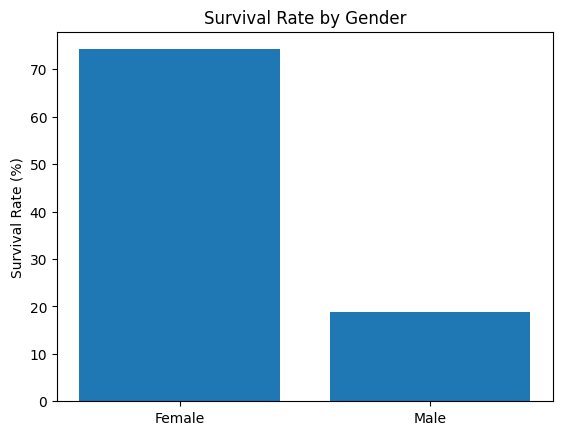

In [59]:
#Graph 1 - explaining the survival rate of sex

female_survival = titanic_df[titanic_df["Sex_female"] == 1]["Survived"].mean() * 100
male_survival = titanic_df[titanic_df["Sex_male"] == 1]["Survived"].mean() * 100

plt.bar(["Female", "Male"], [female_survival, male_survival])

plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Gender")

plt.show()





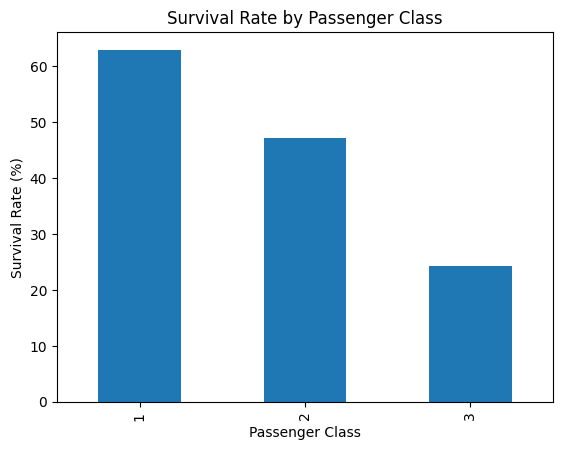

In [60]:
#survival rate by passengers classes

survival_by_class = titanic_df.groupby("Pclass")["Survived"].mean() * 100

survival_by_class.plot(kind="bar")

plt.ylabel("Survival Rate (%)")
plt.xlabel("Passenger Class")
plt.title("Survival Rate by Passenger Class")

plt.show()

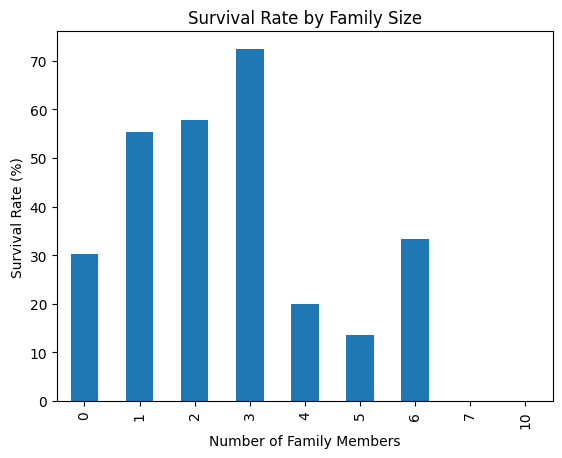

In [61]:
#family survival rates

family_survival = titanic_df.groupby("FamilyCount")["Survived"].mean() * 100

family_survival.plot(kind="bar")

plt.ylabel("Survival Rate (%)")
plt.xlabel("Number of Family Members")
plt.title("Survival Rate by Family Size")

plt.show()

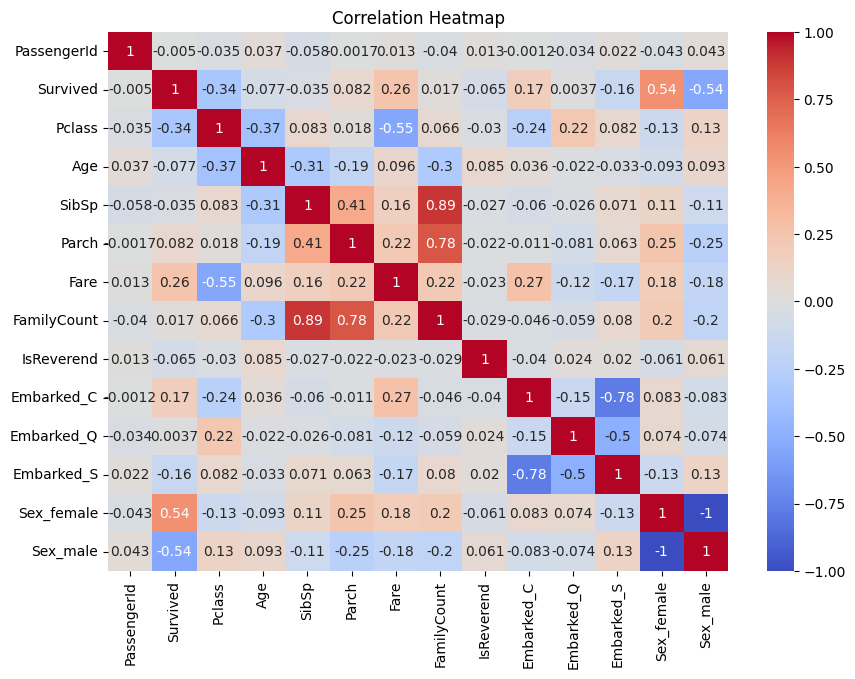

In [63]:
#Heatmap different corelations

plt.figure(figsize=(10, 7))

sns.heatmap(
    titanic_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()



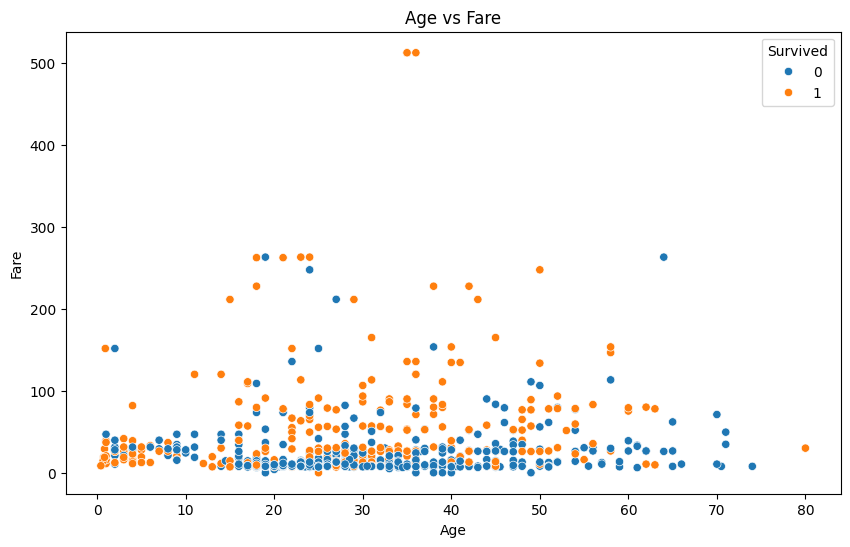

In [64]:
#Age and fare(ticket price)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=titanic_df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()



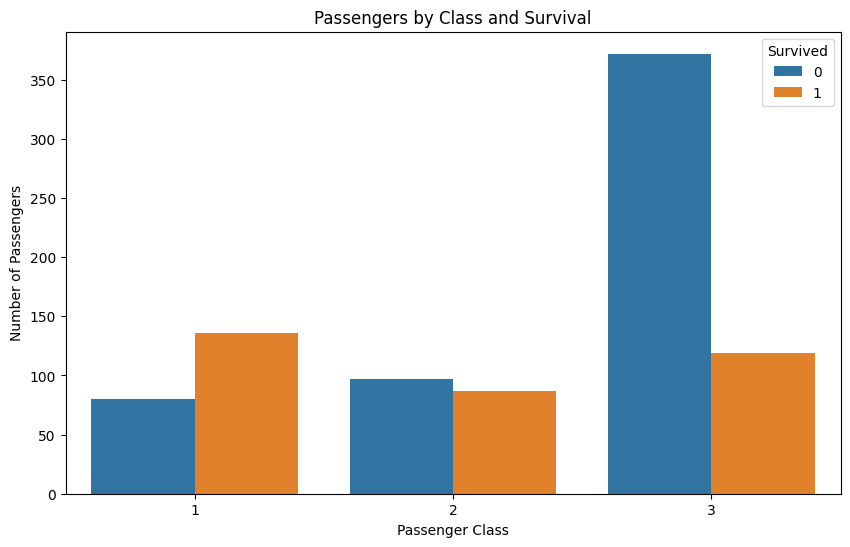

In [66]:
#Class and survival corelation

plt.figure(figsize=(10, 6))

sns.countplot(
    data=titanic_df,
    x="Pclass",
    hue="Survived"
)

plt.title("Passengers by Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()
